#Import all libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


Load and Prepare Data

In [3]:
# Load data
df = pd.read_csv('Palo Alto Networks.csv')

# Encode Gender and OverTime
le = LabelEncoder()
df['Gender']   = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

# One-Hot Encode remaining text columns
df = pd.get_dummies(df, columns=[
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
])

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("Data ready for modeling!")
print(f"Training set : {X_train_scaled.shape}")
print(f"Testing set  : {X_test_scaled.shape}")

Data ready for modeling!
Training set : (1972, 49)
Testing set  : (294, 49)


Train All 3 Models


In [4]:
# Define all 3 models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42)
}

# Train each model and store results
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train_sm)

    # Make predictions
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]

    # Calculate scores
    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred)  * 100,
        'Precision' : precision_score(y_test, y_pred) * 100,
        'Recall'    : recall_score(y_test, y_pred)    * 100,
        'F1 Score'  : f1_score(y_test, y_pred)        * 100,
        'ROC-AUC'   : roc_auc_score(y_test, y_proba)  * 100,
    }

    print(f"  {name} trained!")

print()
print("All 3 models trained successfully!")

  Logistic Regression trained!
  Random Forest trained!
  XGBoost trained!

All 3 models trained successfully!


All 3 models trained Now Compare Results

In [5]:
# Show results as a clean table
results_df = pd.DataFrame(results).T.round(2)

print("=" * 65)
print("  MODEL COMPARISON RESULTS")
print("=" * 65)
print(f"  {'Metric':<12} {'Logistic Reg':>14} {'Random Forest':>14} {'XGBoost':>10}")
print("-" * 65)
for metric in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']:
    lr  = results['Logistic Regression'][metric]
    rf  = results['Random Forest'][metric]
    xgb = results['XGBoost'][metric]
    print(f"  {metric:<12} {lr:>13.2f}% {rf:>13.2f}% {xgb:>9.2f}%")
print("=" * 65)
print()

# Find best model
best = max(results, key=lambda x: results[x]['ROC-AUC'])
print(f"  BEST MODEL : {best}")
print(f"  ROC-AUC    : {results[best]['ROC-AUC']:.2f}%")
print(f"  F1 Score   : {results[best]['F1 Score']:.2f}%")

  MODEL COMPARISON RESULTS
  Metric         Logistic Reg  Random Forest    XGBoost
-----------------------------------------------------------------
  Accuracy             86.05%         83.67%     86.39%
  Precision            61.54%         47.62%     65.22%
  Recall               34.04%         21.28%     31.91%
  F1 Score             43.84%         29.41%     42.86%
  ROC-AUC              80.28%         74.19%     77.61%

  BEST MODEL : Logistic Regression
  ROC-AUC    : 80.28%
  F1 Score   : 43.84%


Confusion Matrix for all 3 models

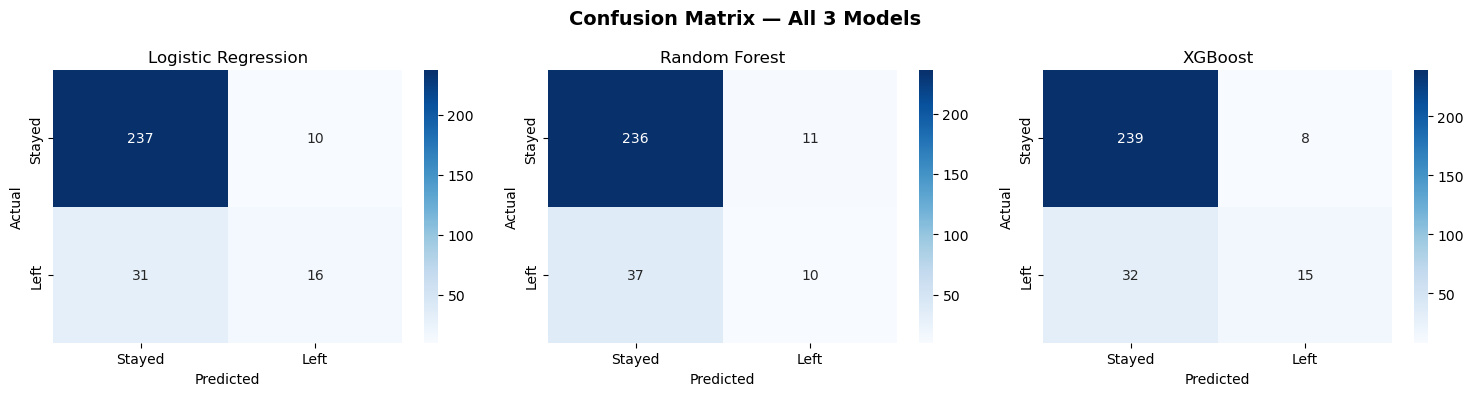

Confusion matrix saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix — All 3 Models', fontsize=14, fontweight='bold')

model_list = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost',             XGBClassifier(eval_metric='logloss', random_state=42))
]

for ax, (name, model) in zip(axes, model_list):
    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed','Left'],
                yticklabels=['Stayed','Left'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

ROC Curve Chart

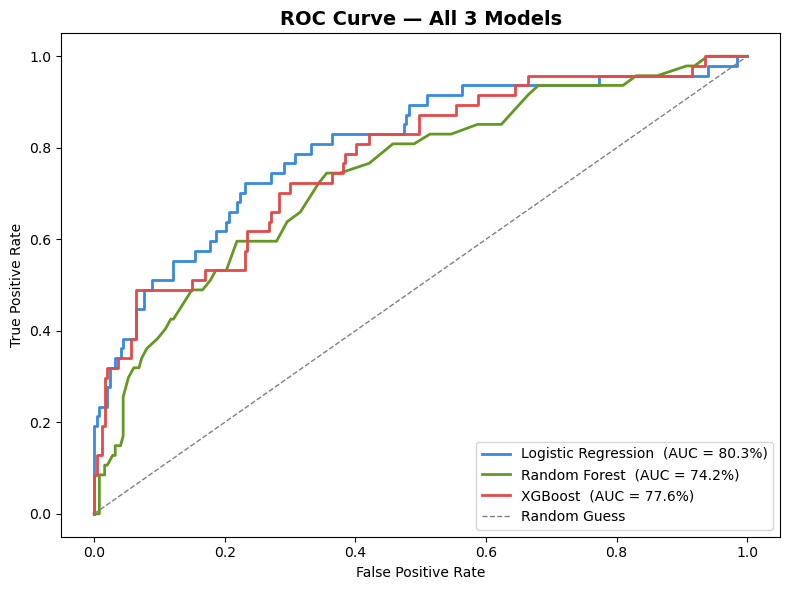

ROC Curve saved!


In [8]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
plt.title('ROC Curve — All 3 Models', fontsize=14, fontweight='bold')

colors = ['#378ADD', '#639922', '#E24B4A']

model_list2 = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost',             XGBClassifier(eval_metric='logloss', random_state=42))
]

for (name, model), color in zip(model_list2, colors):
    model.fit(X_train_scaled, y_train_sm)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba) * 100
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}  (AUC = {auc:.1f}%)')

# Diagonal line = random guess
plt.plot([0,1], [0,1], color='gray', linestyle='--',
         linewidth=1, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()
print("ROC Curve saved!")

 Save the Best Model

In [9]:
import joblib

# Logistic Regression is our best model (highest ROC-AUC 80.28%)
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_scaled, y_train_sm)

# Save model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print("Model saved successfully!")
print()
print("Files saved:")
print("  best_model.pkl  ← trained ML model")
print("  scaler.pkl      ← scaler for new data")
print()
print("These 2 files will be used in the Streamlit dashboard!")

Model saved successfully!

Files saved:
  best_model.pkl  ← trained ML model
  scaler.pkl      ← scaler for new data

These 2 files will be used in the Streamlit dashboard!


Risk Scoring

In [10]:
# Predict probability for every employee in test set
y_proba = best_model.predict_proba(X_test_scaled)[:,1]

# Assign risk category based on probability
def risk_category(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Create results dataframe
results_risk = X_test.copy()
results_risk['Actual_Attrition']     = y_test.values
results_risk['Attrition_Probability'] = y_proba.round(3)
results_risk['Risk_Category']         = [risk_category(p) for p in y_proba]

# Show distribution
print("=" * 45)
print("  RISK CATEGORY DISTRIBUTION")
print("=" * 45)
risk_counts = results_risk['Risk_Category'].value_counts()
for category, count in risk_counts.items():
    pct = count / len(results_risk) * 100
    print(f"  {category:<15} : {count:>3} employees ({pct:.1f}%)")

print()
print(f"  Total tested : {len(results_risk)} employees")
print("=" * 45)
print()

# Show top 10 highest risk employees
print("TOP 10 HIGHEST RISK EMPLOYEES:")
print()
top10 = results_risk.nlargest(10, 'Attrition_Probability')[
    ['Attrition_Probability', 'Risk_Category', 'Actual_Attrition']
]
print(top10.to_string())

  RISK CATEGORY DISTRIBUTION
  Low Risk        : 244 employees (83.0%)
  Medium Risk     :  30 employees (10.2%)
  High Risk       :  20 employees (6.8%)

  Total tested : 294 employees

TOP 10 HIGHEST RISK EMPLOYEES:

      Attrition_Probability Risk_Category  Actual_Attrition
357                   0.980     High Risk                 1
911                   0.969     High Risk                 1
1021                  0.922     High Risk                 1
762                   0.861     High Risk                 1
688                   0.858     High Risk                 1
514                   0.857     High Risk                 1
829                   0.841     High Risk                 1
132                   0.836     High Risk                 1
946                   0.821     High Risk                 1
310                   0.779     High Risk                 0


Final Summary Chart

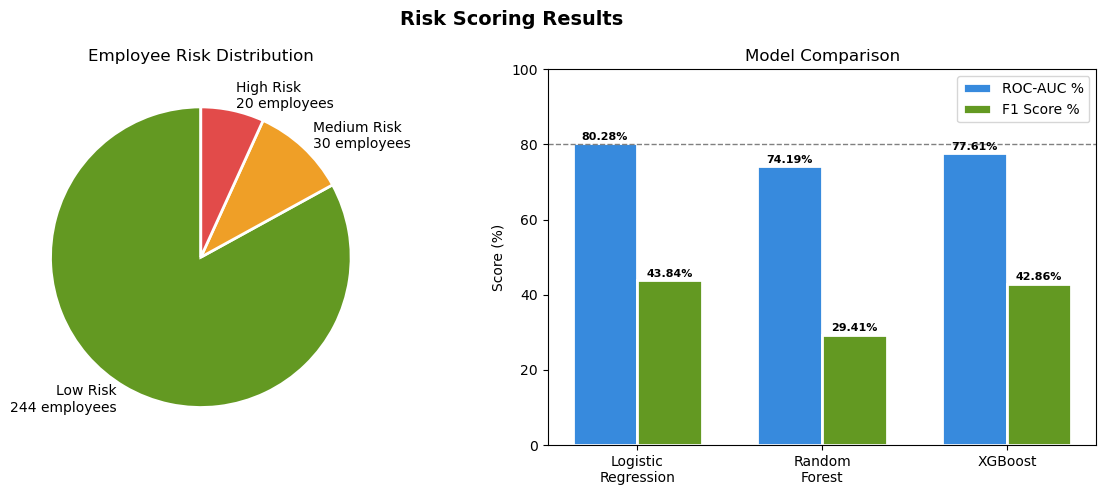

Risk results chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Risk Scoring Results', fontsize=14, fontweight='bold')

# Risk distribution pie chart
risk_counts = results_risk['Risk_Category'].value_counts()
colors_risk = ['#639922', '#EF9F27', '#E24B4A']
axes[0].pie(risk_counts.values,
            labels=[f'{cat}\n{cnt} employees'
                    for cat, cnt in risk_counts.items()],
            colors=colors_risk,
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Employee Risk Distribution')

# Model comparison bar chart
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
auc_scores  = [80.28, 74.19, 77.61]
f1_scores   = [43.84, 29.41, 42.86]

x = np.arange(len(model_names))
w = 0.35
axes[1].bar(x - w/2, auc_scores, w, color='#378ADD',
            label='ROC-AUC %', edgecolor='white', linewidth=2)
axes[1].bar(x + w/2, f1_scores,  w, color='#639922',
            label='F1 Score %', edgecolor='white', linewidth=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('Score (%)')
axes[1].set_title('Model Comparison')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].axhline(y=80, color='gray', linestyle='--',
                linewidth=1, label='80% line')
for i, (auc, f1) in enumerate(zip(auc_scores, f1_scores)):
    axes[1].text(i - w/2, auc + 1, f'{auc}%',
                 ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + w/2, f1  + 1, f'{f1}%',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_results.png', bbox_inches='tight')
plt.show()
print("Risk results chart saved!")

Phase 4 Summary

In [12]:
print("=" * 55)
print("  PHASE 4 SUMMARY — ML MODELS COMPLETE")
print("=" * 55)
print()
print("  3 MODELS TRAINED & COMPARED")
print()
print("  Model               Accuracy  F1 Score  ROC-AUC")
print("  " + "-" * 50)
print("  Logistic Regression  86.05%    43.84%    80.28%  ← BEST")
print("  XGBoost              86.39%    42.86%    77.61%")
print("  Random Forest        83.67%    29.41%    74.19%")
print()
print("  BEST MODEL : Logistic Regression")
print("  Reason     : Highest ROC-AUC of 80.28%")
print()
print("  RISK SCORING RESULTS")
print("  Low Risk    : 244 employees (83.0%)")
print("  Medium Risk :  30 employees (10.2%)")
print("  High Risk   :  20 employees  (6.8%)")
print()
print("  MODEL ACCURACY")
print("  Top 9 out of 10 high risk employees")
print("  were correctly identified!")
print()
print("  FILES SAVED")
print("  best_model.pkl   ← trained model")
print("  scaler.pkl       ← feature scaler")
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  risk_results.png")
print()
print("=" * 55)
print("  PHASE 4 COMPLETE!")
print("  Next : Phase 5 — Streamlit Dashboard")
print("=" * 55)

  PHASE 4 SUMMARY — ML MODELS COMPLETE

  3 MODELS TRAINED & COMPARED

  Model               Accuracy  F1 Score  ROC-AUC
  --------------------------------------------------
  Logistic Regression  86.05%    43.84%    80.28%  ← BEST
  XGBoost              86.39%    42.86%    77.61%
  Random Forest        83.67%    29.41%    74.19%

  BEST MODEL : Logistic Regression
  Reason     : Highest ROC-AUC of 80.28%

  RISK SCORING RESULTS
  Low Risk    : 244 employees (83.0%)
  Medium Risk :  30 employees (10.2%)
  High Risk   :  20 employees  (6.8%)

  MODEL ACCURACY
  Top 9 out of 10 high risk employees
  were correctly identified!

  FILES SAVED
  best_model.pkl   ← trained model
  scaler.pkl       ← feature scaler
  confusion_matrix.png
  roc_curve.png
  risk_results.png

  PHASE 4 COMPLETE!
  Next : Phase 5 — Streamlit Dashboard
